<a href="https://colab.research.google.com/github/kxrrym03/Fake-News-Detection/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving news_dataset.csv to news_dataset.csv


In [ ]:
df = pd.read_csv('news_dataset.csv')
df.shape

(6000, 5)

In [ ]:
df.head()

,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1


In [ ]:
df.tail()

,title,text,subject,date,label
5995,Exiled Venezuelan opposition magistrates resur...,SANTIAGO (Reuters) - A group of opposition-app...,worldnews,"October 19, 2017",1
5996,Plague outbreak in Madagascar kills 20: WHO,NAIROBI (Reuters) - An outbreak of plague has ...,worldnews,"September 29, 2017",1
5997,"Trump to visit Asia in November, North Korea i...",WASHINGTON (Reuters) - Donald Trump will trave...,worldnews,"September 29, 2017",1
5998,Melania Trump calls taped comments by Donald T...,(Reuters) - Melania Trump rose to her husband’...,politicsNews,"October 18, 2016",1
5999,"#BoycottPenzeys: HATEFUL, DIVISIVE Penzeys Spi...","Bill Penzey, the owner of Penzeys Spices, wrot...",politics,"Dec 2, 2016",0


In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(5995, 5)

In [ ]:
df.describe()

,label
count,5995.000000
mean,0.499583
std,0.500042
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5995 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    5995 non-null   object
 1   text     5995 non-null   object
 2   subject  5995 non-null   object
 3   date     5995 non-null   object
 4   label    5995 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 281.0+ KB


In [ ]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [ ]:
df.dtypes

,0
title,object
text,object
subject,object
date,object
label,int64


## Data Visualization


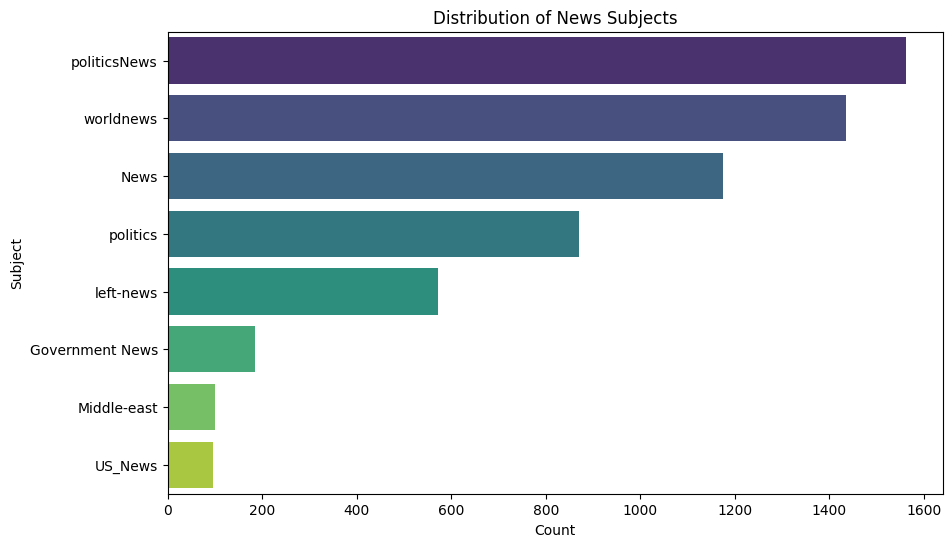

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='subject', order=df['subject'].value_counts().index, palette='viridis')
plt.title('Distribution of News Subjects')
plt.xlabel('Count')
plt.ylabel('Subject')
plt.show()

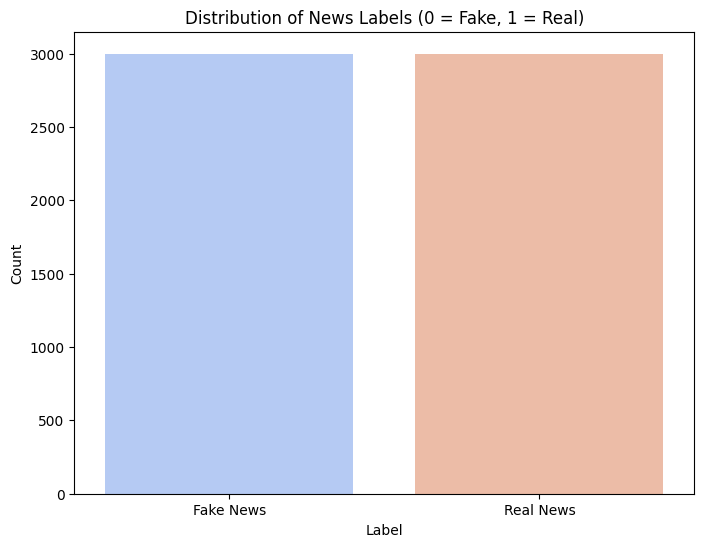

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='label', palette='coolwarm')
plt.title('Distribution of News Labels (0 = Fake, 1 = Real)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake News', 'Real News'])
plt.show()

### Word Count Statistics


In [ ]:
# Calculate word count for the 'text' column
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Display descriptive statistics for word count
print("Descriptive statistics for 'word_count' column:")
display(df['word_count'].describe())

Descriptive statistics for 'word_count' column:


,word_count
count,5995.000000
mean,403.924771
std,356.832757
min,0.000000
25%,204.000000
50%,359.000000
75%,509.000000
max,8135.000000


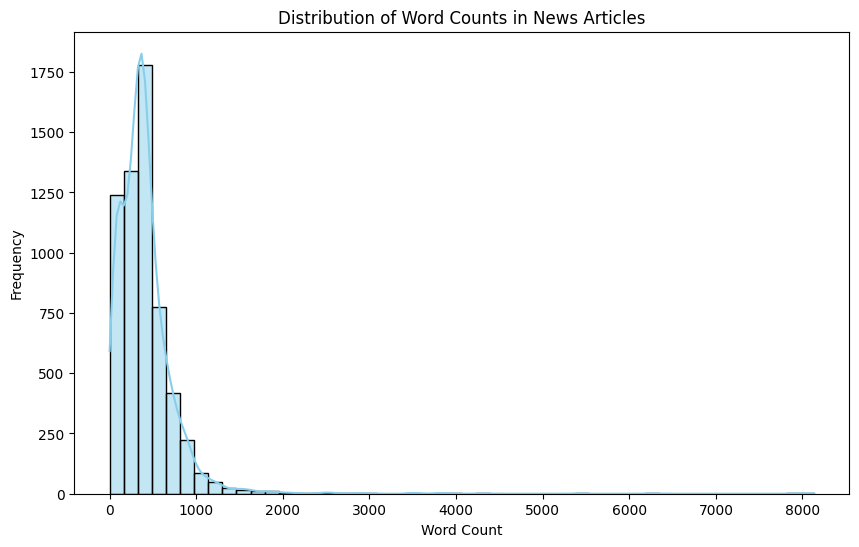

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Word Counts in News Articles')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

### Sentiment Analysis



In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon
nltk.download('vader_lexicon', quiet=True)

True

In [ ]:
# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment_scores(text):
    return sia.polarity_scores(text)

# Apply the function to the 'text' column
df['sentiment_scores'] = df['text'].apply(get_sentiment_scores)

# Extract compound, negative, neutral, and positive scores into separate columns
df['compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])
df['neg'] = df['sentiment_scores'].apply(lambda x: x['neg'])
df['neu'] = df['sentiment_scores'].apply(lambda x: x['neu'])
df['pos'] = df['sentiment_scores'].apply(lambda x: x['pos'])

# Display the first few rows with new sentiment columns
display(df[['text', 'compound', 'neg', 'neu', 'pos', 'label']].head())

,text,compound,neg,neu,pos,label
0,A whole lot of evangelical Trump voters just d...,0.9454,0.054,0.846,0.100,0
1,GENEVA (Reuters) - China signaled on Wednesday...,-0.9826,0.141,0.760,0.098,1
2,,0.0000,0.000,0.000,0.000,0
3,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,0.6008,0.084,0.818,0.097,0
4,WASHINGTON (Reuters) - Critics of a plan for t...,0.8957,0.059,0.848,0.093,1


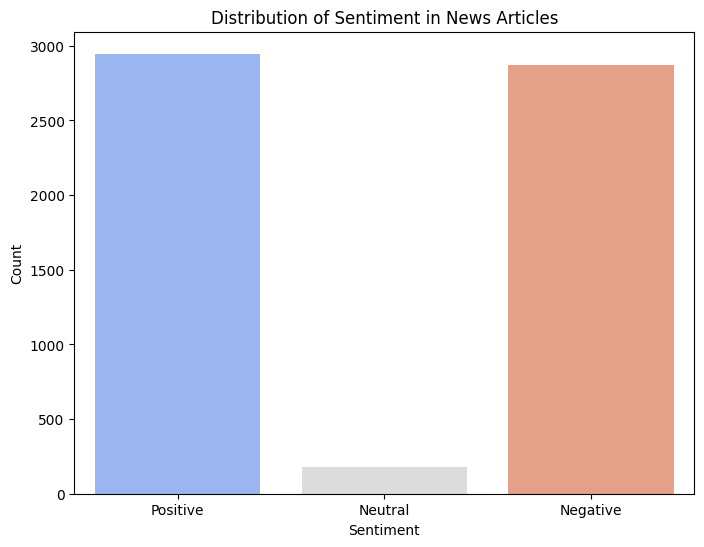

In [ ]:
# Categorize sentiment based on compound score
def categorize_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['compound'].apply(categorize_sentiment)

# Visualize the distribution of sentiment categories
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sentiment', order=['Positive', 'Neutral', 'Negative'], palette='coolwarm')
plt.title('Distribution of Sentiment in News Articles')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

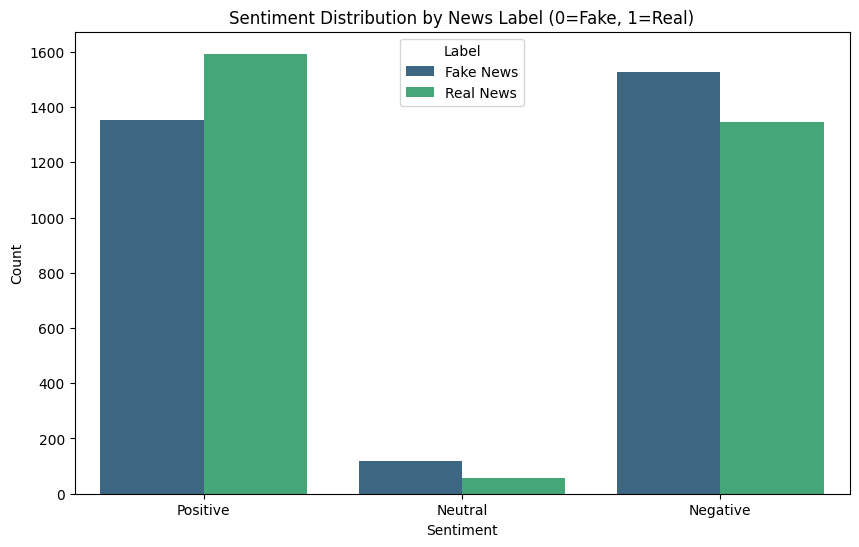

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sentiment', hue='label', order=['Positive', 'Neutral', 'Negative'], palette='viridis')
plt.title('Sentiment Distribution by News Label (0=Fake, 1=Real)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.legend(title='Label', labels=['Fake News', 'Real News'])
plt.show()

### Text Preprocessing

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab') # Explicitly download punkt_tab without quiet=True

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-z]', ' ', text)
    # Tokenize the text
    words = word_tokenize(text)
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join words back into a string
    return ' '.join(words)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Applying the preprocessing function to the 'text' column:

In [ ]:
df['cleaned_text'] = df['text'].apply(preprocess_text)
display(df[['text', 'cleaned_text']].head())

,text,cleaned_text
0,A whole lot of evangelical Trump voters just d...,whole lot evangelical trump voter discovered g...
1,GENEVA (Reuters) - China signaled on Wednesday...,geneva reuters china signaled wednesday willin...
2,,
3,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,wsj mary kissel nail dem debate three candidat...
4,WASHINGTON (Reuters) - Critics of a plan for t...,washington reuters critic plan u government ce...


### TF-IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features to manage dimensionality

# Fit and transform the 'cleaned_text' column
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])

# Display the shape of the TF-IDF matrix and some feature names
print(f"Shape of TF-IDF matrix: {X_tfidf.shape}")
print(f"Number of features (unique words): {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"Top 20 TF-IDF features:\n{tfidf_vectorizer.get_feature_names_out()[:20]}")

Shape of TF-IDF matrix: (5995, 5000)
Number of features (unique words): 5000
Top 20 TF-IDF features:
['abadi' 'abandon' 'abandoned' 'abc' 'abdullah' 'abe' 'abedin' 'ability'
 'able' 'aboard' 'abortion' 'abroad' 'absence' 'absolute' 'absolutely'
 'absurd' 'abu' 'abuse' 'abused' 'academic']


### Top 20 Most Frequent Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
count_vectorizer = CountVectorizer(max_features=5000) # Use same max_features for consistency

# Fit and transform the 'cleaned_text' column to get word counts
X_count = count_vectorizer.fit_transform(df['cleaned_text'])

# Sum the counts for each word across all documents
word_counts = np.sum(X_count.toarray(), axis=0)

# Get feature names
feature_names = count_vectorizer.get_feature_names_out()

# Create a dictionary of words and their counts
word_freq = dict(zip(feature_names, word_counts))

# Sort the words by frequency in descending order
sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# Display the top 20 most frequent words
print("Top 20 most frequent words:")
for word, count in sorted_word_freq[:20]:
    print(f"{word}: {count}")

Top 20 most frequent words:
said: 18441
trump: 18066
state: 8460
president: 8005
would: 7278
year: 5764
people: 5371
republican: 5363
one: 5262
new: 4252
also: 4226
government: 4126
reuters: 4081
time: 3947
clinton: 3933
house: 3830
donald: 3748
obama: 3538
american: 3442
country: 3427


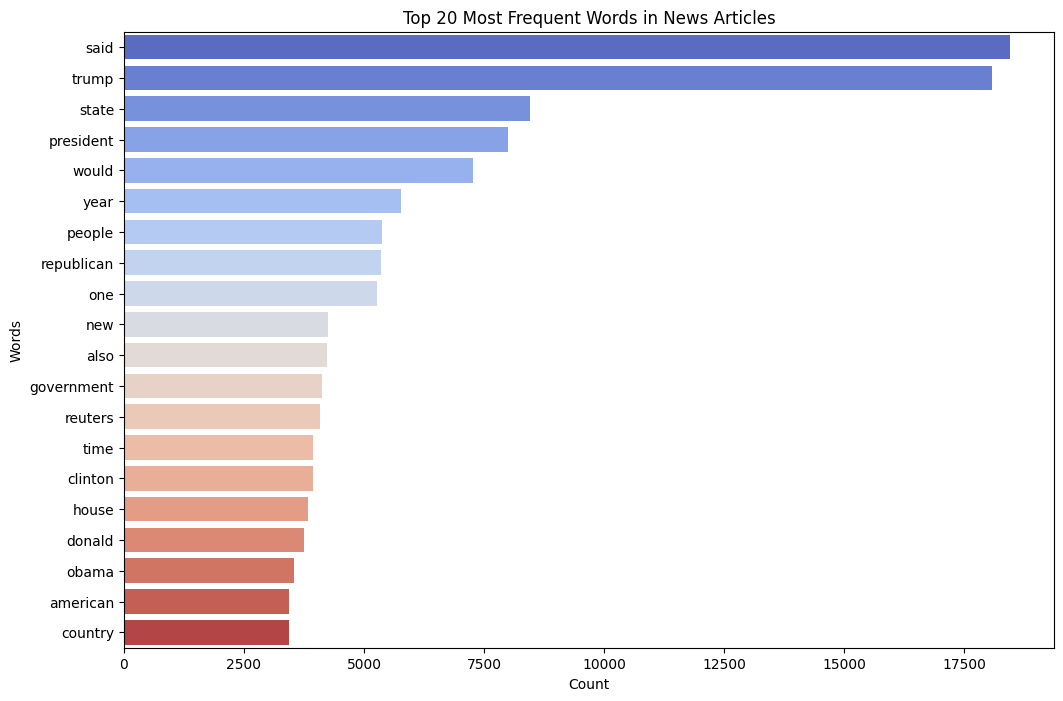

In [ ]:
words = [item[0] for item in sorted_word_freq[:20]]
counts = [item[1] for item in sorted_word_freq[:20]]

plt.figure(figsize=(12, 8))
sns.barplot(x=counts, y=words, palette='coolwarm')
plt.title('Top 20 Most Frequent Words in News Articles')
plt.xlabel('Count')
plt.ylabel('Words')
plt.show()

In [ ]:
average_sentiment_score = df['compound'].mean()
print(f"Average Sentiment Score: {average_sentiment_score:.3f}")

Average Sentiment Score: 0.002


In [ ]:
!pip install wordcloud

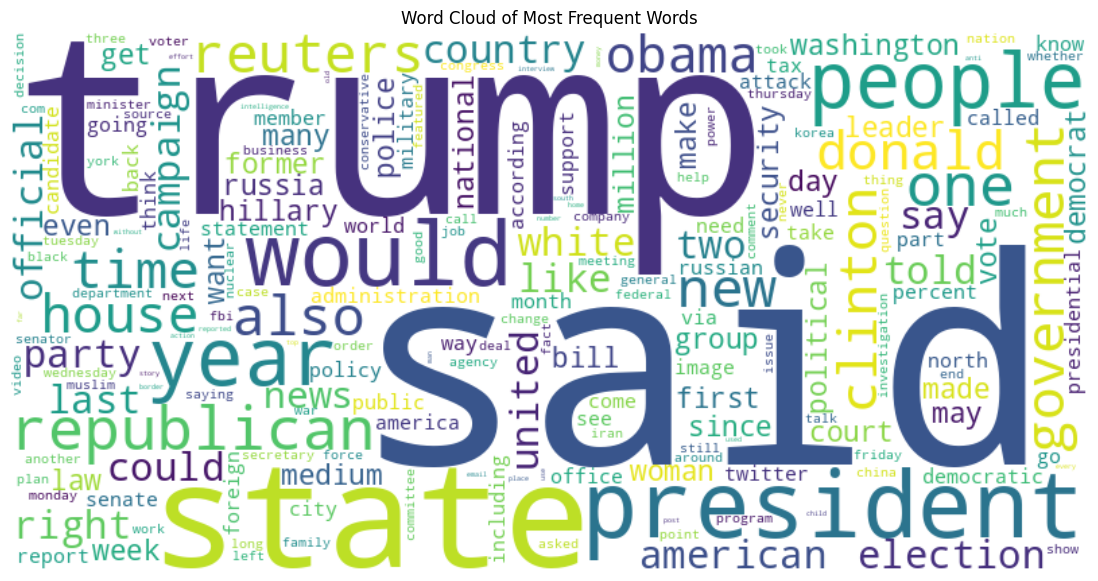

In [ ]:
from wordcloud import WordCloud

# Convert the sorted word frequency list to a dictionary for WordCloud
wordcloud_dict = dict(sorted_word_freq)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_dict)

# Display the word cloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words')
plt.show()

In [ ]:
average_sentiment_by_subject = df.groupby('subject')['compound'].mean().sort_values(ascending=False)
display(average_sentiment_by_subject)

,compound
subject,
politicsNews,0.246951
politics,0.066355
Government News,-0.035066
US_News,-0.076315
News,-0.111485
left-news,-0.115248
Middle-east,-0.124960
worldnews,-0.143252


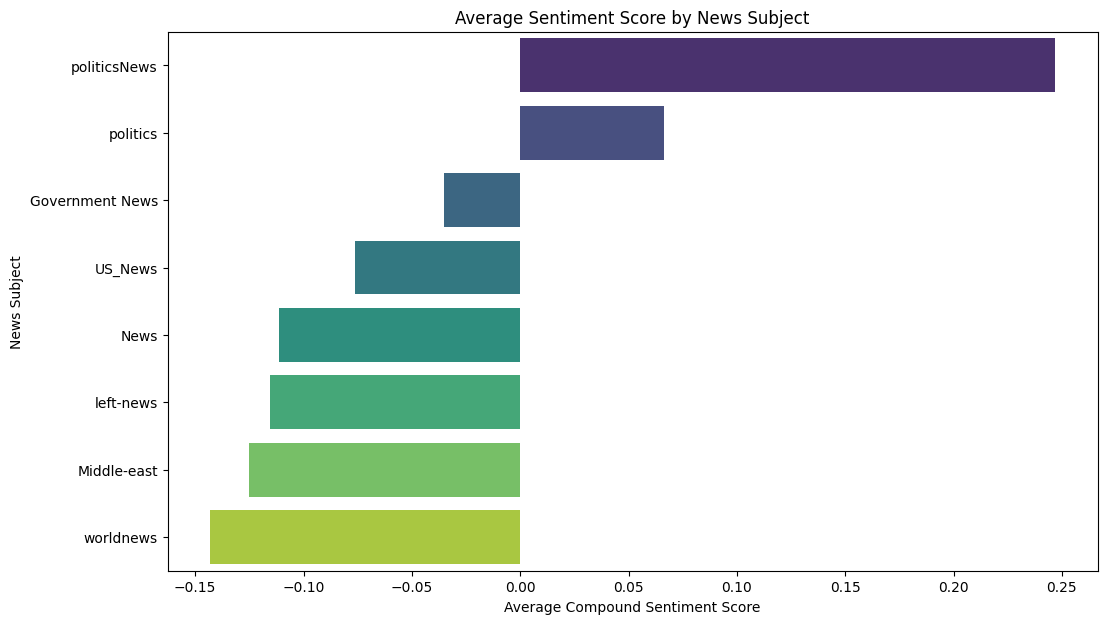

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=average_sentiment_by_subject.values, y=average_sentiment_by_subject.index, palette='viridis')
plt.title('Average Sentiment Score by News Subject')
plt.xlabel('Average Compound Sentiment Score')
plt.ylabel('News Subject')
plt.show()

## Machine Learning: Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Define features
X = df['cleaned_text']
y = df['label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4796,)
Shape of X_test: (1199,)
Shape of y_train: (4796,)
Shape of y_test: (1199,)


In [ ]:
# Transform the training and testing text data using the fitted TF-IDF vectorizer
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (4796, 5000)
Shape of X_test_tfidf: (1199, 5000)


## Model Training and Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model
model.fit(X_train_tfidf, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9725

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       600
           1       0.96      0.98      0.97       599

    accuracy                           0.97      1199
   macro avg       0.97      0.97      0.97      1199
weighted avg       0.97      0.97      0.97      1199



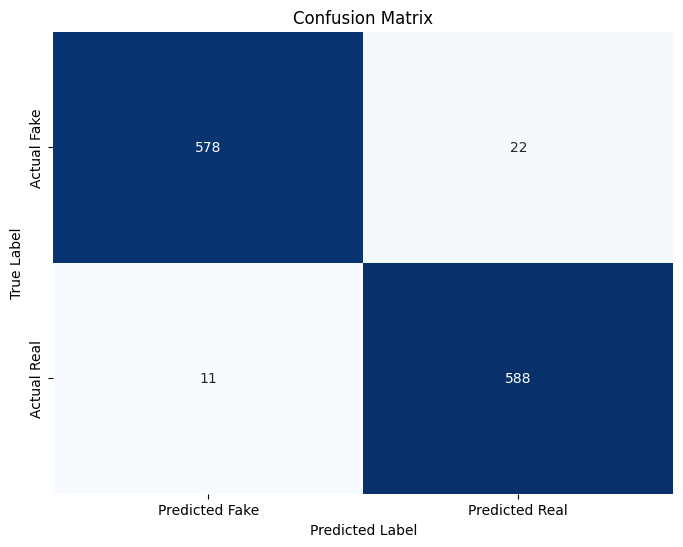

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()